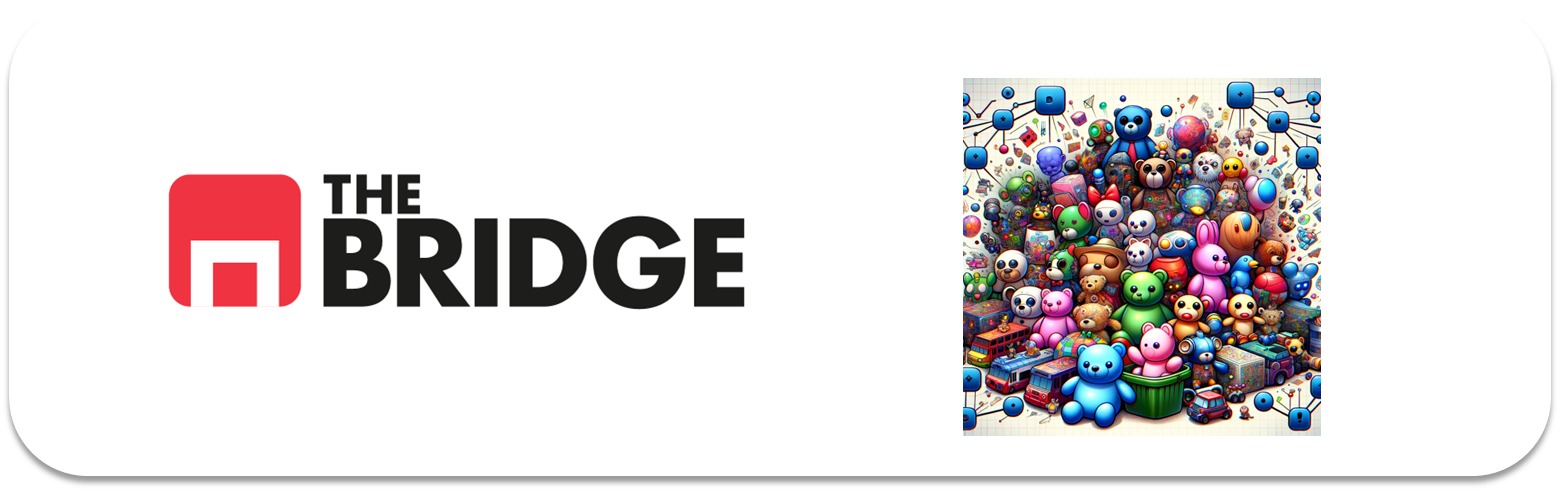

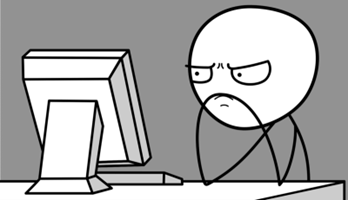

Para ejercitarte y afianzar lo aprendido sobre **K-Means**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Common imports
import numpy as np
import os
import pandas as pd

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### Entendiendo el problema de negocio

En este notebook vamos a hacer un análisis de datos tirando de clusterizaciones para evaluar si existen grupos en nuestros productos, en este caso medicamentos, y posteriormente poder etiquetarlos. Poseemos información como rating, efectividad, efectos secundarios, entre otros.

### Ejercicio 1

Importa los datos, "./data/drugLibTrain_raw.tsv", que contiene un dataset con diferentes fármacos, sus efectos y ratings de los clientes de dichos fármacos. Realiza una inspección preliminar y quita las columnas que consideres innecesarias.

In [29]:
import pandas as pd

df = pd.read_csv("./data/drugLibTrain_raw.tsv", sep="\t")
df.head(10)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
5,2372,propecia,1,Ineffective,Severe Side Effects,hair loss,"after taking propecia for over a year, startin...","Low sex drive, before i started taking this dr...",one pill once daily
6,1043,vyvanse,9,Highly Effective,Mild Side Effects,add,"My mood has noticably improved, I have more en...","a few experiences of nausiea, heavy moodswings...",I had began taking 20mg of Vyvanse for three m...
7,2715,elavil,10,Considerably Effective,No Side Effects,depression,Although this drug was originally prescribed f...,None.,"One a day, taken about an hour before bedtime."
8,1591,xanax,10,Highly Effective,No Side Effects,panic disorder,This simply just works fast and without any of...,I really don't have any side effects other tha...,I first started taking this at 3 times per day...
9,1686,claritin,1,Ineffective,Extremely Severe Side Effects,allergies,none - did nothing to help allergies. i just h...,I had some horrifying mental and physical side...,took one 10 mg pill nightly.


### Ejercicio 2: MiniEDA

Como es un problema no supervisado (vamos a intentar agrupar los medicamentos sin tener una referencia o target inicial), no hay split, vamos directos al miniEDA. Analiza qué variables son descartables en función de su porcentaje de cardinalidad. Es decir obten la cardinalidad y su porcentaje para cada posible feature y crea un dataset nuevo descartando las features que creas conveniente. NOTA: Como simplificación, descarta la columna con url.

In [3]:
n = len(df)


# Cardinalidad absoluta y relativa
cardinalidad = (
    df.nunique()
    .to_frame("cardinalidad")
    .assign(porcentaje=lambda x: x["cardinalidad"] / n * 100)
)
cardinalidad


,cardinalidad,porcentaje
Unnamed: 0,3107,100.000000
urlDrugName,502,16.157065
rating,10,0.321854
effectiveness,5,0.160927
sideEffects,5,0.160927
condition,1426,45.896363
benefitsReview,3031,97.553911
sideEffectsReview,2813,90.537496
commentsReview,3046,98.036691


In [4]:
# Umbrales
umbral_alto = 80   # porcentaje
umbral_bajo = 2    # cardinalidad mínima

descartables = cardinalidad[
    (cardinalidad["porcentaje"] > umbral_alto) |
    (cardinalidad["cardinalidad"] < umbral_bajo)
].index.tolist()

# Añadir la columna URL explícitamente
if "urlDrug" in df.columns:
    descartables.append("urlDrug")

descartables = list(set(descartables))  # evitar duplicados
descartables


['benefitsReview', 'commentsReview', 'sideEffectsReview', 'Unnamed: 0']

In [5]:
df_clean = df.drop(columns=descartables)
df_clean.head()


,urlDrugName,rating,effectiveness,sideEffects,condition
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps
3,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux
4,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia


### Ejercicio 3

Construye un train set (llámalo X) sólo con las features que hayas seleccionado del ejercicio anterior (es decir las que no hayas descartado como posibles features) 

In [38]:
X = df[["rating", "effectiveness", "sideEffects",'Unnamed: 0']].copy()


In [39]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   rating         3107 non-null   int64 
 1   effectiveness  3107 non-null   object
 2   sideEffects    3107 non-null   object
 3   Unnamed: 0     3107 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 97.2+ KB


### Ejercicio 4 

Trasforma las features que consideres necesario (categóricas y numéricas) y luego aplica el escalado que consideres necesario.

In [40]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = ["effectiveness", "sideEffects"]
num_cols = ["rating"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = ohe.fit_transform(X[cat_cols])
X_cat = pd.DataFrame(X_cat, columns=ohe.get_feature_names_out(cat_cols))



In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])
X_num = pd.DataFrame(X_num, columns=num_cols)


In [42]:
X_transformed = pd.concat([X_num, X_cat], axis=1)
X_transformed.shape


(3107, 11)

### Ejercicio 5: Otención de K, aproximación visual

Analiza la relación entre features (con scatter plots) una vez transformadas para comprobar si existe visualmente algún indicio del número de clústeres que podríamos estar buscando. Por otro lado este análisis nos puede hacer descartar alguna feature o generar una nueva

In [43]:
X.describe()


,rating,Unnamed: 0
count,3107.000000,3107.000000
mean,7.006115,2080.607016
std,2.937582,1187.998828
min,1.000000,0.000000
25%,5.000000,1062.500000
50%,8.000000,2092.000000
75%,9.000000,3092.500000
max,10.000000,4161.000000


In [45]:
X_transformed.columns


Index(['rating', 'effectiveness_Considerably Effective',
       'effectiveness_Highly Effective', 'effectiveness_Ineffective',
       'effectiveness_Marginally Effective',
       'effectiveness_Moderately Effective',
       'sideEffects_Extremely Severe Side Effects',
       'sideEffects_Mild Side Effects', 'sideEffects_Moderate Side Effects',
       'sideEffects_No Side Effects', 'sideEffects_Severe Side Effects'],
      dtype='object')

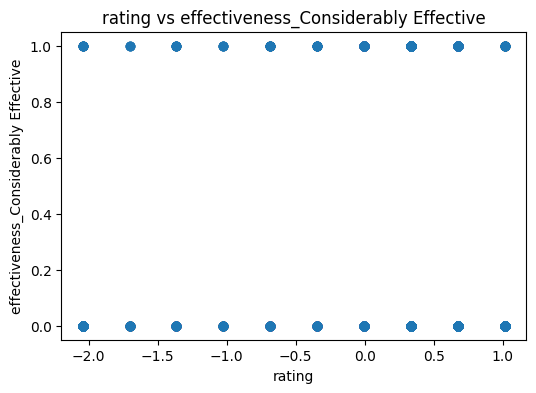

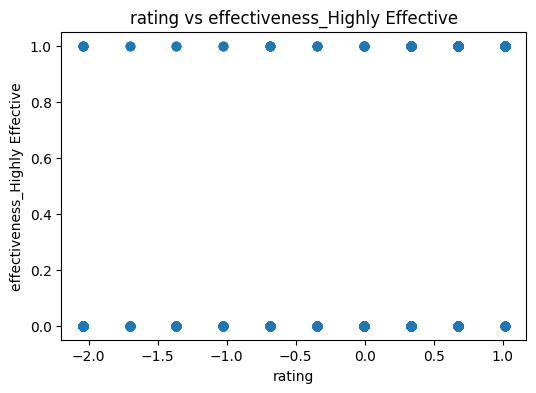

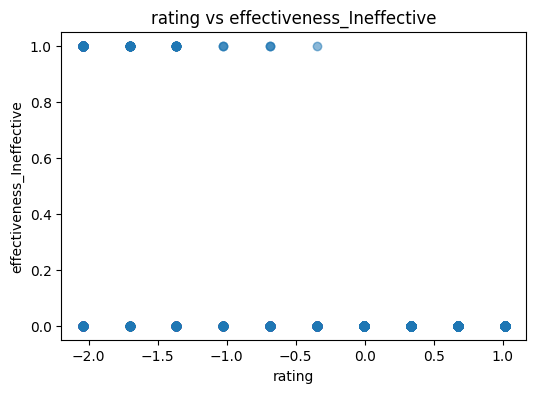

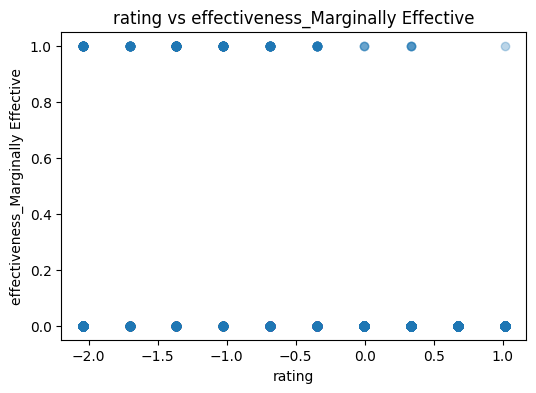

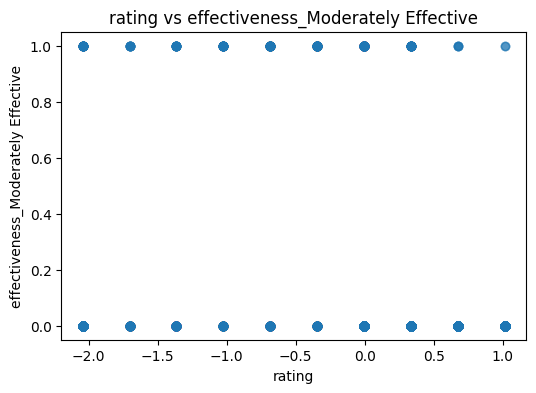

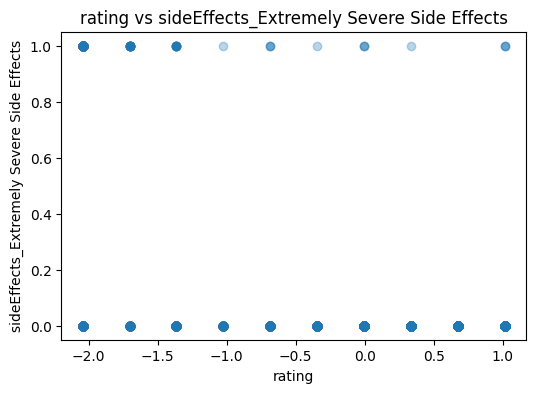

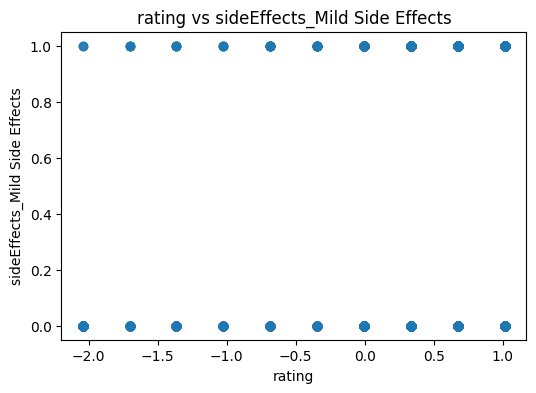

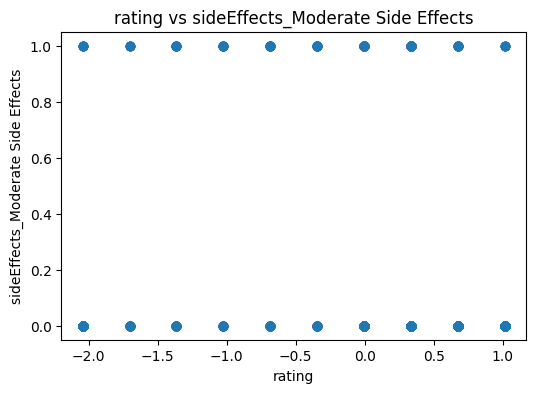

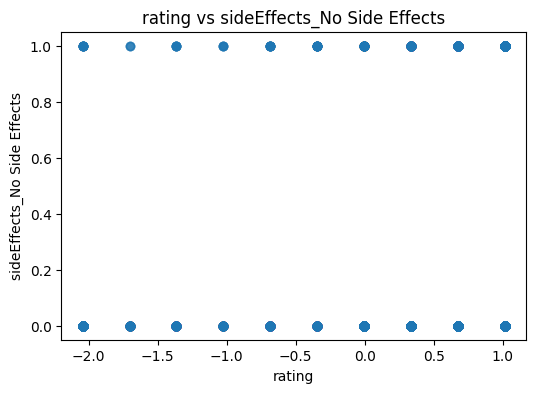

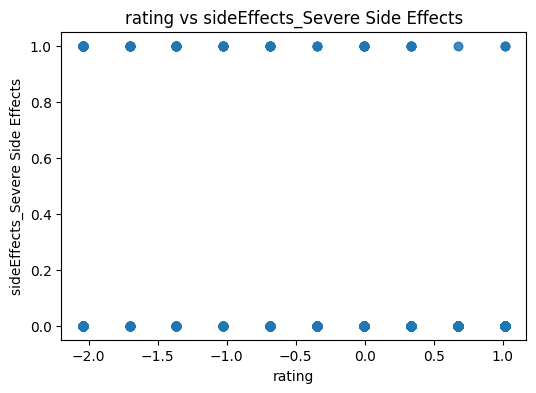

In [46]:
import matplotlib.pyplot as plt

for col in X_transformed.columns:
    if col != "rating":
        plt.figure(figsize=(6,4))
        plt.scatter(X_transformed["rating"], X_transformed[col], alpha=0.3)
        plt.xlabel("rating")
        plt.ylabel(col)
        plt.title(f"rating vs {col}")
        plt.show()

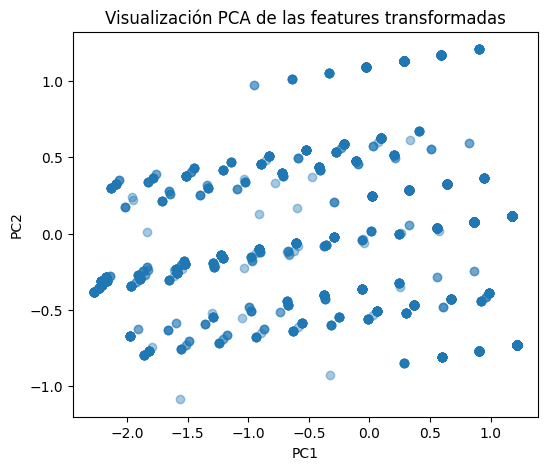

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA de las features transformadas")
plt.show()


### Ejercicio 6: Obtención de K, método del codo

Evalua diferentes valores K y escoge uno a partir del método del codo/elbow de inercia.

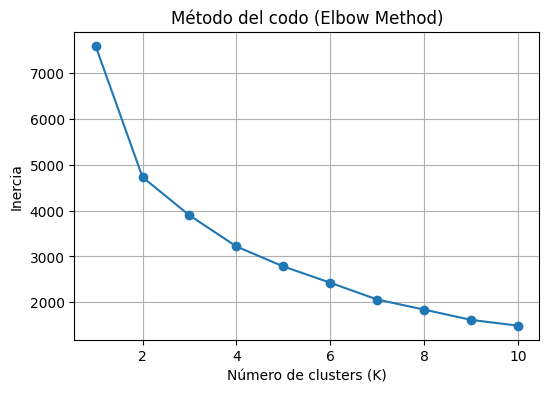

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_values = range(1, 11)   # puedes ampliar si quieres

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_transformed)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_values, inertias, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo (Elbow Method)")
plt.grid(True)
plt.show()

In [49]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_transformed)

X_transformed["cluster"] = labels


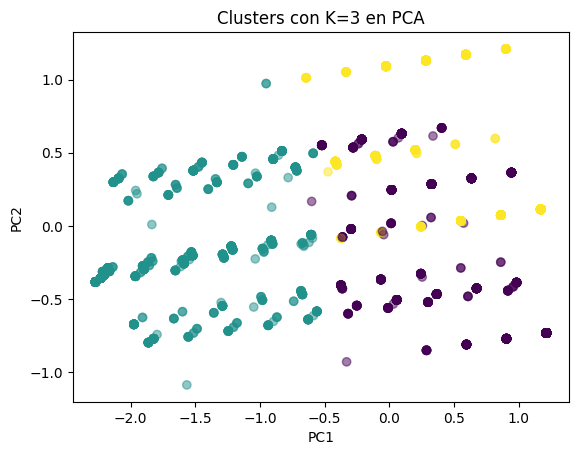

In [50]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis", alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters con K=3 en PCA")
plt.show()


### Ejercicio 7: Obtención de K, Score de Silueta

Comprueba el ajuste de k obteniendo el k que maximiza el score de silueta y pinta un gráfico de la evolución de dicho score con k. Usa los valores de k que hayas probado en el ejercicio anterior.

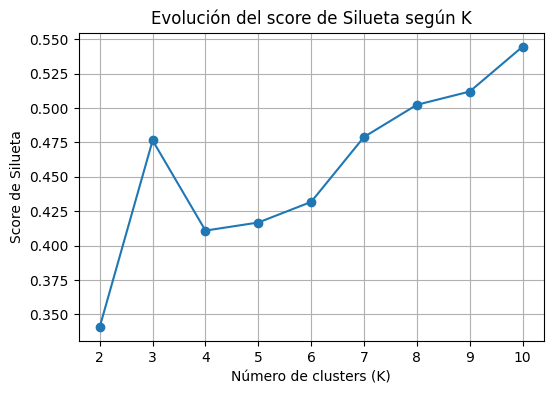

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K_values = range(2, 11)   # Silueta no se define para K=1

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_values, silhouette_scores, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Score de Silueta")
plt.title("Evolución del score de Silueta según K")
plt.grid(True)
plt.show()


### Ejercicio 8: Obtención de K, diagrama de silueta

Para completar el estudio de k, muestra el diagramde silueta para k=2,3,4,5 y decide con este datos y los anteriores el valor de k a probar. NOTA: En la realidad, podríamos probar perfectamente k=2 y k=3 y luego que "Negocio" decidiera cuál le es más útil, aquí lo completamos por practicar todo lo aprendido

K=2, Silhouette Score=0.3410


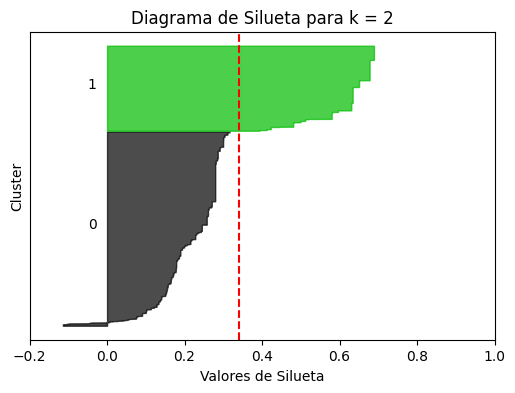

K=3, Silhouette Score=0.4764


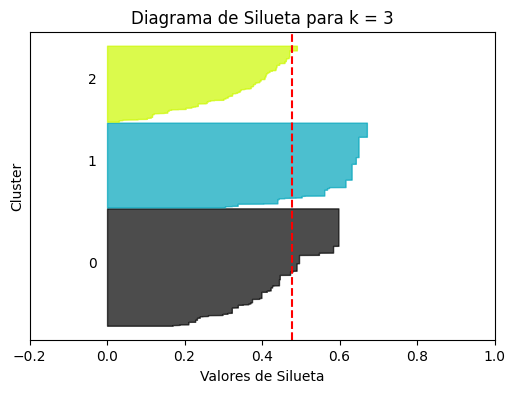

K=4, Silhouette Score=0.4109


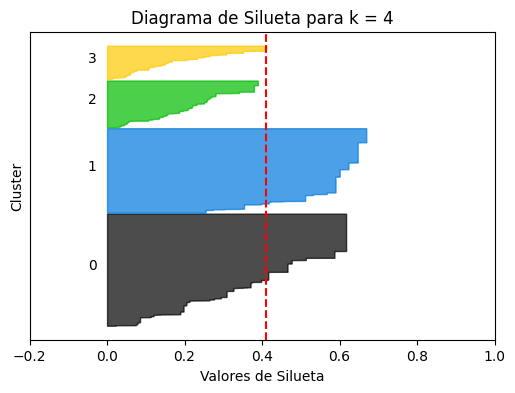

K=5, Silhouette Score=0.4168


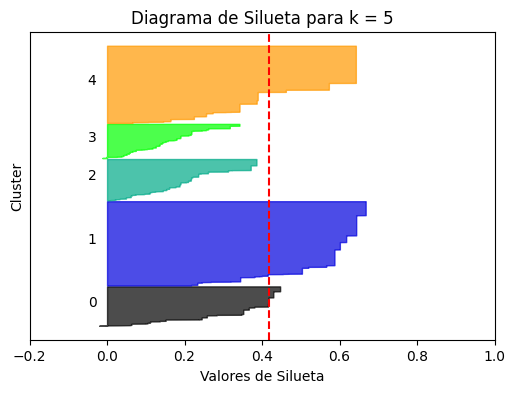

In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

Ks = [2, 3, 4, 5]

for k in Ks:
    fig, ax = plt.subplots(figsize=(6, 4))

    # Entrenar KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_transformed)

    # Score de silueta global
    silhouette_avg = silhouette_score(X_transformed, labels)
    print(f"K={k}, Silhouette Score={silhouette_avg:.4f}")

    # Silueta por muestra
    sample_silhouette_values = silhouette_samples(X_transformed, labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"Diagrama de Silueta para k = {k}")
    ax.set_xlabel("Valores de Silueta")
    ax.set_ylabel("Cluster")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xlim([-0.2, 1])
    plt.show()

### Ejercico 9:

En general, una diferencia entre el proceso de construcción de un modelo no supervisado y un supervisado es que el ajuste de algunos hiperparámetros (como el número de clústeres) es anterior a la construcción del modelo. Por eso, construye un K-means para el valor (o valores) de K escogidos.

In [53]:
from sklearn.cluster import KMeans

# Entrenar el modelo con el K elegido
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_transformed)

# Añadir las etiquetas al dataset transformado
X_transformed["cluster"] = labels

# Mostrar cuántos elementos hay en cada cluster
X_transformed["cluster"].value_counts()

cluster
0    1311
1     947
2     849
Name: count, dtype: int64

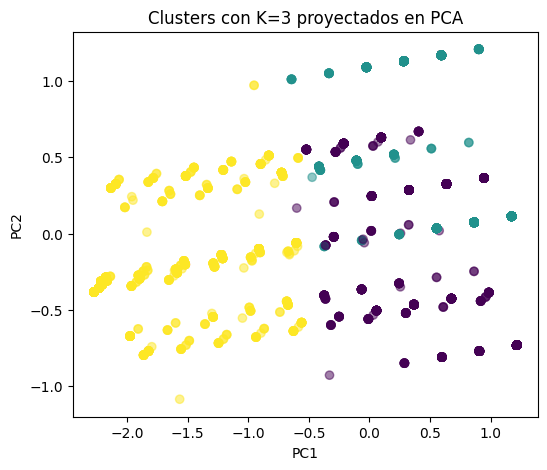

In [54]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis", alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters con K=3 proyectados en PCA")
plt.show()


In [55]:
X_transformed.groupby("cluster")["rating"].mean()


cluster
0    0.561214
1    0.513837
2   -1.439759
Name: rating, dtype: float64

In [56]:
X_transformed.groupby("cluster")[[
    col for col in X_transformed.columns if col.startswith("effectiveness_")
]].mean()


,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective
cluster,,,,,
0,0.330282,0.579710,0.000000,0.006102,0.083905
1,0.379092,0.506864,0.001056,0.012672,0.100317
2,0.160188,0.106007,0.289753,0.196702,0.247350


In [57]:
X_transformed.groupby("cluster")[[
    col for col in X_transformed.columns if col.startswith("sideEffects_")
]].mean()


,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
cluster,,,,,
0,0.005339,0.000000,0.284516,0.652937,0.057208
1,0.000000,1.000000,0.000000,0.000000,0.000000
2,0.197880,0.084806,0.283863,0.087161,0.346290


### Ejercicio 10

Vamos a comprobar resultados, analizando los valores medios y distribución de cada uno de los clústeres para el k óptimo. Si tuvieras más de un posible valor de k a probar, analiza aquí el de mayor score de silueta. Y utiliza el siguiente ejercicio para el otro. Además de hacer un describe de las features por clúster, pinta estos con un pairplot considerando sideEffects y rating como x e y (o viceversa) y el clúster como hue (color). Compara el resultado con los clústeres sugeridos en el ejercicio 5.

In [58]:
X_transformed.groupby("cluster").describe().T


cluster                                          0           1           2
rating                          count  1311.000000  947.000000  849.000000
                                mean      0.561214    0.513837   -1.439759
                                std       0.438653    0.411596    0.566170
                                min      -0.683024   -0.683024   -2.044907
                                25%       0.338389    0.338389   -2.044907
...                                            ...         ...         ...
sideEffects_Severe Side Effects min       0.000000    0.000000    0.000000
                                25%       0.000000    0.000000    0.000000
                                50%       0.000000    0.000000    0.000000
                                75%       0.000000    0.000000    1.000000
                                max       1.000000    0.000000    1.000000

[88 rows x 3 columns]

In [59]:
X_transformed.groupby("cluster").mean()

,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
cluster,,,,,,,,,,,
0,0.561214,0.330282,0.579710,0.000000,0.006102,0.083905,0.005339,0.000000,0.284516,0.652937,0.057208
1,0.513837,0.379092,0.506864,0.001056,0.012672,0.100317,0.000000,1.000000,0.000000,0.000000,0.000000
2,-1.439759,0.160188,0.106007,0.289753,0.196702,0.247350,0.197880,0.084806,0.283863,0.087161,0.346290


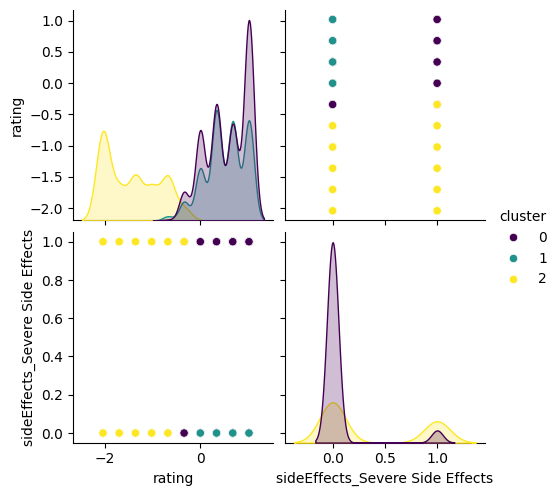

In [60]:
import seaborn as sns
import pandas as pd

df_plot = X_transformed.copy()

sns.pairplot(
    df_plot,
    vars=["rating", "sideEffects_Severe Side Effects"],
    hue="cluster",
    palette="viridis"
)
plt.show()


In [65]:
# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42)
kmeans_3.fit(X_transformed)
inertia_k3 = kmeans_3.inertia_

inertia_k3

3896.4268985894496

### Ejercicio 11, EXTRA: Más valores de K

Repite el análisis del ejercicio 10 para un K diferente pero que consideres que tiene sentido aplicar.

In [61]:
from sklearn.cluster import KMeans

kmeans_2 = KMeans(n_clusters=2, random_state=42)
labels_2 = kmeans_2.fit_predict(X_transformed)

X_transformed["cluster_2"] = labels_2

In [62]:
X_transformed.groupby("cluster_2").describe().T

cluster_2                0           1
rating  count  2258.000000  849.000000
        mean      0.541344   -1.439759
        std       0.428060    0.566170
        min      -0.683024   -2.044907
        25%       0.338389   -2.044907
...                    ...         ...
cluster min       0.000000    2.000000
        25%       0.000000    2.000000
        50%       0.000000    2.000000
        75%       1.000000    2.000000
        max       1.000000    2.000000

[96 rows x 2 columns]

In [63]:
X_transformed.groupby("cluster_2").mean()


,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects,cluster
cluster_2,,,,,,,,,,,,
0,0.541344,0.350753,0.549159,0.000443,0.008857,0.090788,0.00310,0.419398,0.165190,0.379097,0.033215,0.419398
1,-1.439759,0.160188,0.106007,0.289753,0.196702,0.247350,0.19788,0.084806,0.283863,0.087161,0.346290,2.000000


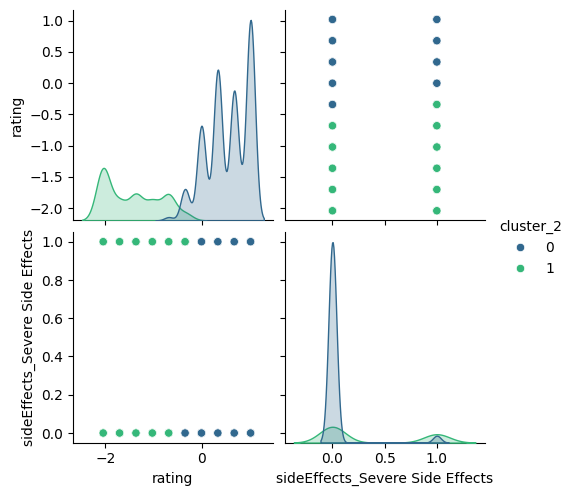

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = X_transformed.copy()

sns.pairplot(
    df_plot,
    vars=["rating", "sideEffects_Severe Side Effects"],
    hue="cluster_2",
    palette="viridis"
)
plt.show()


In [66]:
from sklearn.cluster import KMeans

# K = 2
kmeans_2 = KMeans(n_clusters=2, random_state=42)
kmeans_2.fit(X_transformed)
inertia_k2 = kmeans_2.inertia_

inertia_k2

5282.452461827341